In [1]:
# Import app from Custom library
from Graph.graph import app
from IPython.display import Image, display

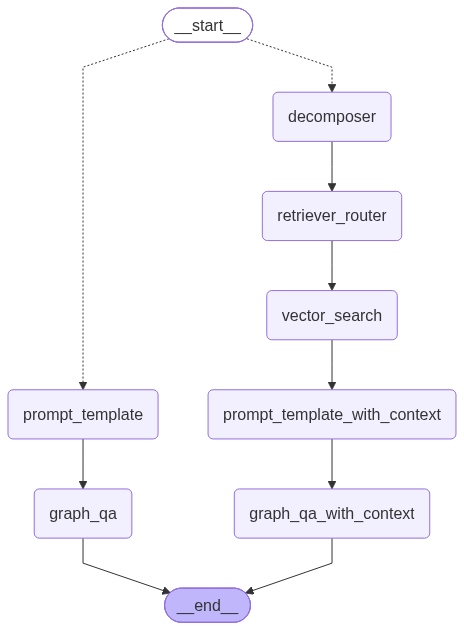

In [4]:
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
graph_qa_result = app.invoke({"question": "find top 5 models related to \"text classification\""})

---ROUTE QUESTION---
---ROUTE QUESTION TO VECTOR SEARCH---
---RETRIEVER ROUTER -> ['Model']---


> Entering new RetrievalQA chain...


Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: "CALL db.index.vector.queryNodes($vector_index_name, $top_k * $effective_search_ratio, $query_vector) YIELD node, score WITH node, score LIMIT $top_k RETURN reduce(str='', k IN ['model_id', 'pipeline_tag', 'config'] | str + '\\n' + k + ': ' + coalesce(toString(node[k]), '')) AS text, node{node_id: node.model_id, label: 'Model'} AS metadata, s


> Finished chain.


In [11]:
graph_qa_result['documents']

{'query': 'Neo4j graph query: Given the list of model IDs from subquery1 (parameter $model_ids), return detailed model nodes. Cypher:\n\nMATCH (m:Model)\nWHERE m.model_id IN $model_ids\nRETURN m.model_id AS id, m.name AS name, m.description AS description, m.metrics AS metrics, m.repo AS repo, m.popularity AS popularity\nORDER BY m.popularity DESC\nLIMIT 5',
 'result': [{'model_id': 'models/Adi-0-0-Gupta/Embedding-v1',
   'pipeline_tag': 'sentence-similarity',
   'downloads': '19',
   'config': "{'architectures': ['bertmodel'], 'model_type': 'bert', 'tokenizer_config': {'cls_token': '[cls]', 'mask_token': '[mask]', 'pad_token': '[pad]', 'sep_token': '[sep]', 'unk_token': '[unk]'}}",
   'repository_name': 'Adi-0-0-Gupta/Embedding-v1',
   'repository_id': 'models/Adi-0-0-Gupta/Embedding-v1'},
  {'model_id': 'models/Adi-0-0-Gupta/Embedding-v0',
   'pipeline_tag': 'sentence-similarity',
   'downloads': '102',
   'config': "{'architectures': ['bertmodel'], 'model_type': 'bert', 'tokenizer_c

In [12]:
graph_qa_result = app.invoke({"question": "What models were created by a specific author, e.g  \"google\"?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO GRAPH QA---


> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (au:Author)<-[:CREATED_BY]-(r:Repository)<-[:IS_A]-(m:Model) WHERE au.username = 'google' RETURN m.model_id

> Finished chain.


In [13]:
graph_qa_result['documents']

{'query': 'What models were created by a specific author, e.g  "google"?',
 'result': [{'m.model_id': 'models/google/bert2bert_L-24_wmt_de_en'},
  {'m.model_id': 'models/google/bert2bert_L-24_wmt_en_de'},
  {'m.model_id': 'models/google/bert_for_seq_generation_L-24_bbc_encoder'},
  {'m.model_id': 'models/google/bert_uncased_L-10_H-128_A-2'},
  {'m.model_id': 'models/google/bert_uncased_L-10_H-256_A-4'},
  {'m.model_id': 'models/google/bert_uncased_L-10_H-512_A-8'},
  {'m.model_id': 'models/google/bert_uncased_L-10_H-768_A-12'},
  {'m.model_id': 'models/google/bert_uncased_L-12_H-128_A-2'},
  {'m.model_id': 'models/google/bert_uncased_L-12_H-256_A-4'},
  {'m.model_id': 'models/google/bert_uncased_L-12_H-512_A-8'}]}

In [14]:
result = app.invoke({"question": "How many models are there in total?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO GRAPH QA---


> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (m:Model) RETURN count(m)

> Finished chain.


In [5]:
result.keys()

dict_keys(['question', 'documents', 'prompt'])

In [6]:
result['documents']

{'query': 'How many models are there in total?',
 'result': [{'count(m)': 708377}]}

In [7]:
result['subqueries']

KeyError: 'subqueries'